# Exploratory Data Analysis of US Domestic Flights (2015–2017)

**Name:** Mobin Abedian  
**Dataset:** Airline Delay and Cancellation Data (2009–2018)  
**Source:** Kaggle Dataset by Yuanyu Wendy Mu

## Project Overview

This project performs an exploratory data analysis (EDA) on United States domestic flight data from 2015 to 2017. The analysis focuses on flight delays, cancellations, carrier performance, airport activity, and temporal patterns in air transportation.

The main goals of this project are:

- Understanding the structure and quality of the dataset
- Identifying patterns in delays and cancellations
- Comparing airlines and airports
- Exploring relationships between operational variables
- Producing visual and statistical summaries

The analysis is conducted using Python, pandas, matplotlib, and seaborn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
pd.set_option("display.max_columns",None)
sb.set_style("whitegrid")

## Loading Flight Data

The dataset is provided as separate CSV files for each year.  
In this project, flight records from 2015, 2016, and 2017 are combined into a single dataframe for analysis.

In [3]:
df_2015 = pd.read_csv("../data/exploratory_data_analysis_of_airline_delays_and_cancellations/2015.csv",encoding='ISO-8859-1')
df_2016 = pd.read_csv("../data/exploratory_data_analysis_of_airline_delays_and_cancellations/2016.csv",encoding='ISO-8859-1')
df_2017 = pd.read_csv("../data/exploratory_data_analysis_of_airline_delays_and_cancellations/2017.csv",encoding='ISO-8859-1')

In [4]:
df = pd.concat(
    [df_2015,df_2016,df_2017],
    ignore_index=True
)

## Initial Data Inspection

In this section, we inspect the structure of the dataset using:

- `shape()` to view dataset dimensions
- `head()` to preview sample rows
- `info()` to inspect data types and missing values
- `describe()` to generate summary statistics for numerical variables

In [5]:
df.shape

(17111358, 28)

In [6]:
df.head()

,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
0,2015-01-01,NK,195,MCO,FLL,2147,2143.0,-4.0,15.0,2158.0,2238.0,7.0,2250,2245.0,-5.0,0.0,NaN,0.0,63.0,62.0,40.0,177.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01,NK,197,LGA,FLL,1050,1104.0,14.0,20.0,1124.0,1354.0,9.0,1404,1403.0,-1.0,0.0,NaN,0.0,194.0,179.0,150.0,1076.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01,NK,198,FLL,MCO,700,712.0,12.0,19.0,731.0,803.0,10.0,757,813.0,16.0,0.0,NaN,0.0,57.0,61.0,32.0,177.0,0.0,0.0,16.0,0.0,0.0,NaN
3,2015-01-01,NK,199,IAH,LAS,2240,2251.0,11.0,8.0,2259.0,2343.0,4.0,2356,2347.0,-9.0,0.0,NaN,0.0,196.0,176.0,164.0,1222.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-01,NK,200,IAH,ORD,623,620.0,-3.0,15.0,635.0,830.0,10.0,855,840.0,-15.0,0.0,NaN,0.0,152.0,140.0,115.0,925.0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17111358 entries, 0 to 17111357
Data columns (total 28 columns):
 #   Column               Dtype  
---  ------               -----  
 0   FL_DATE              str    
 1   OP_CARRIER           str    
 2   OP_CARRIER_FL_NUM    int64  
 3   ORIGIN               str    
 4   DEST                 str    
 5   CRS_DEP_TIME         int64  
 6   DEP_TIME             float64
 7   DEP_DELAY            float64
 8   TAXI_OUT             float64
 9   WHEELS_OFF           float64
 10  WHEELS_ON            float64
 11  TAXI_IN              float64
 12  CRS_ARR_TIME         int64  
 13  ARR_TIME             float64
 14  ARR_DELAY            float64
 15  CANCELLED            float64
 16  CANCELLATION_CODE    str    
 17  DIVERTED             float64
 18  CRS_ELAPSED_TIME     float64
 19  ACTUAL_ELAPSED_TIME  float64
 20  AIR_TIME             float64
 21  DISTANCE             float64
 22  CARRIER_DELAY        float64
 23  WEATHER_DELAY        float64
 24  NAS_DEL

In [8]:
df.describe()

,OP_CARRIER_FL_NUM,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
count,1.711136e+07,1.711136e+07,1.688144e+07,1.688141e+07,1.687475e+07,1.687475e+07,1.686633e+07,1.686633e+07,1.711136e+07,1.686633e+07,1.683156e+07,1.711136e+07,1.711136e+07,1.711134e+07,1.683156e+07,1.683156e+07,1.711136e+07,3.057151e+06,3.057151e+06,3.057151e+06,3.057151e+06,3.057151e+06,0.0
mean,2.132214e+03,1.330184e+03,1.334193e+03,9.345809e+00,1.634567e+01,1.356037e+03,1.467802e+03,7.465423e+00,1.491334e+03,1.472350e+03,4.088201e+00,1.393449e-02,2.417634e-03,1.446642e+02,1.396208e+02,1.158210e+02,8.428433e+02,1.969906e+01,2.782354e+00,1.472193e+01,8.409136e-02,2.431198e+01,NaN
std,1.732574e+03,4.880600e+02,5.010820e+02,4.031023e+01,9.037232e+00,5.028149e+02,5.287876e+02,5.751211e+00,5.141182e+02,5.331055e+02,4.240217e+01,1.172191e-01,4.910997e-02,7.628076e+01,7.553560e+01,7.336019e+01,6.173912e+02,5.612670e+01,2.211699e+01,3.167008e+01,2.555855e+00,4.563615e+01,NaN
min,1.000000e+00,1.000000e+00,1.000000e+00,-2.340000e+02,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-2.380000e+02,0.000000e+00,0.000000e+00,1.000000e+00,1.400000e+01,4.000000e+00,2.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
25%,7.250000e+02,9.150000e+02,9.170000e+02,-5.000000e+00,1.100000e+01,9.320000e+02,1.050000e+03,4.000000e+00,1.105000e+03,1.054000e+03,-1.400000e+01,0.000000e+00,0.000000e+00,8.800000e+01,8.400000e+01,6.100000e+01,3.860000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
50%,1.672000e+03,1.325000e+03,1.329000e+03,-2.000000e+00,1.400000e+01,1.341000e+03,1.507000e+03,6.000000e+00,1.520000e+03,1.511000e+03,-6.000000e+00,0.000000e+00,0.000000e+00,1.250000e+02,1.210000e+02,9.700000e+01,6.720000e+02,1.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,3.000000e+00,NaN
75%,3.063000e+03,1.735000e+03,1.742000e+03,6.000000e+00,1.900000e+01,1.756000e+03,1.913000e+03,9.000000e+00,1.920000e+03,1.917000e+03,7.000000e+00,0.000000e+00,0.000000e+00,1.770000e+02,1.720000e+02,1.470000e+02,1.084000e+03,1.800000e+01,0.000000e+00,1.800000e+01,0.000000e+00,3.000000e+01,NaN
max,9.855000e+03,2.359000e+03,2.400000e+03,2.755000e+03,2.250000e+02,2.400000e+03,2.400000e+03,4.140000e+02,2.400000e+03,2.400000e+03,2.189000e+03,1.000000e+00,1.000000e+00,7.180000e+02,7.840000e+02,7.230000e+02,4.983000e+03,2.142000e+03,1.934000e+03,1.605000e+03,8.270000e+02,1.756000e+03,NaN


## Variable Categorization

To better organize the exploratory analysis, the variables are grouped based on their semantic meaning and operational role in the dataset.

The main categories include:

- Flight identifiers
- Time-related variables
- Delay measurements
- Operational flight metrics
- Status indicators such as cancellations and diversions

This categorization simplifies later analysis and improves interpretability of tables and visualizations.

In [9]:
flight_identifier_columns = [
    "OP_CARRIER",
    "OP_CARRIER_FL_NUM",
    "ORIGIN",
    "DEST"
]

In [10]:
delay_columns = [
    "FL_DATE",
    "CRS_DEP_TIME",
    "DEP_TIME",
    "CRS_ARR_TIME",
    "ARR_TIME"
]

In [11]:
delay_columns = [
    "DEP_DELAY",
    "ARR_DELAY",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

In [12]:
operational_columns = [
    "DISTANCE",
    "AIR_TIME",
    "TAXI_IN",
    "TAXI_OUT",
    "ACTUAL_ELAPSED_TIME",
    "CRS_ELAPSED_TIME"
]

In [13]:
status_indicator_columns = [
    "CANCELLED",
    "DIVERTED"
]

In [14]:
df["Unnamed: 27"].value_counts(dropna=False)

Unnamed: 27
NaN    17111358
Name: count, dtype: int64

#  Missing Values and Data Quality

This section investigates missing values and data quality issues in the flight dataset.

Missing data are important in airline operational datasets because some variables are only available under specific conditions. For example, delay cause variables may only be populated for delayed flights, while arrival-related variables may be missing for cancelled flights.

Understanding these patterns is essential before performing further statistical analysis and visualization.

In [15]:
missing_counts = df.isnull().sum()

missing_percentages = (
    df.isnull().mean() * 100
)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_percentages
})

missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

In [16]:
missing_summary[
    missing_summary["missing_count"] > 0 
]

,missing_count,missing_percentage
Unnamed: 27,17111358,100.000000
CANCELLATION_CODE,16872920,98.606551
NAS_DELAY,14054207,82.133791
LATE_AIRCRAFT_DELAY,14054207,82.133791
SECURITY_DELAY,14054207,82.133791
WEATHER_DELAY,14054207,82.133791
CARRIER_DELAY,14054207,82.133791
ARR_DELAY,279795,1.635142
ACTUAL_ELAPSED_TIME,279795,1.635142
AIR_TIME,279795,1.635142


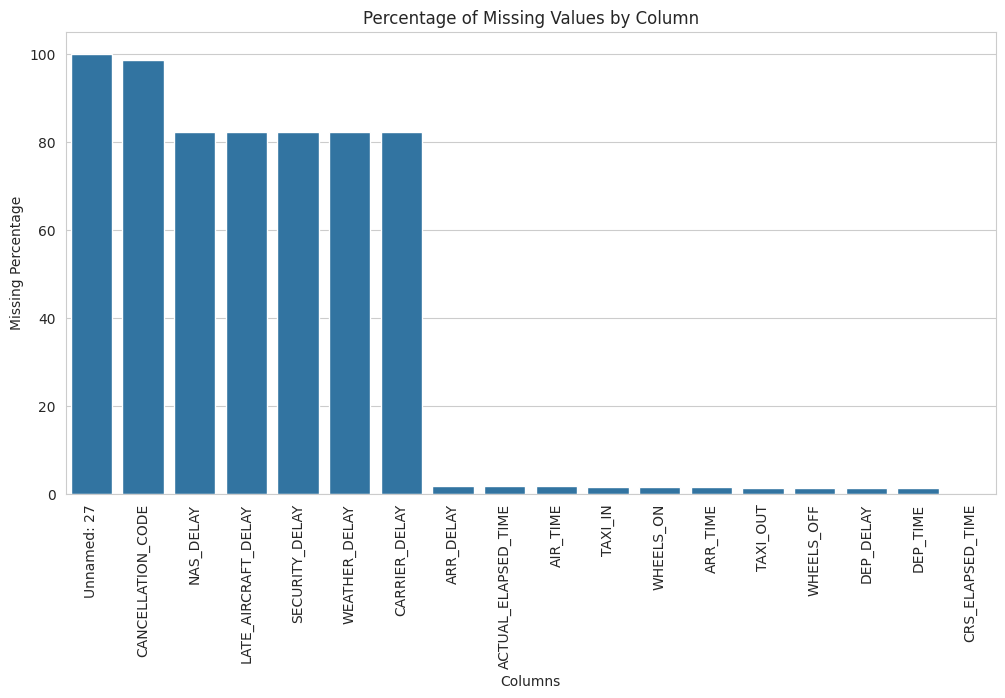

In [17]:
missing_plot = (
    missing_summary[
        missing_summary["missing_percentage"] > 0
    ]
    .sort_values(
        by="missing_percentage",
        ascending=False
    )
)

plt.figure(figsize=(12, 6))
sb.barplot(
    x=missing_plot.index,
    y=missing_plot["missing_percentage"]
)

plt.xticks(rotation=90)
plt.ylabel("Missing Percentage")
plt.xlabel("Columns")
plt.title("Percentage of Missing Values by Column")
plt.show()

The dataset contains several non-random missing value patterns, particularly in cancellation and delay-related variables.

## Relationship Between Cancellation Status and Cancellation Codes

The relationship between `CANCELLED` and `CANCELLATION_CODE` was examined to determine whether missing cancellation codes are meaningful.

The results show that cancellation codes are only present for cancelled flights and are missing for all non-cancelled flights. This indicates that the missing values in `CANCELLATION_CODE` are completely structural rather than accidental.

In [18]:
pd.crosstab(
    df["CANCELLED"],
    df["CANCELLATION_CODE"].isnull(),
    margins=True
)

CANCELLATION_CODE,False,True,All
CANCELLED,,,
0.0,0,16872920,16872920
1.0,238438,0,238438
All,238438,16872920,17111358


Cancellation codes are only present for cancelled flights, confirming that the missing values are structurally meaningful.

## Missing Arrival Delay Values

The relationship between flight cancellation status and missing arrival delay values was investigated.

All cancelled flights contain missing arrival delay values, which is expected because cancelled flights do not have actual arrival times. Additionally, a smaller number of non-cancelled flights also contain missing arrival delays, likely due to diverted flights or incomplete operational records.

In [19]:
pd.crosstab(
    df["CANCELLED"],
    df["ARR_DELAY"].isnull(),
    margins=True
)

ARR_DELAY,False,True,All
CANCELLED,,,
0.0,16831563,41357,16872920
1.0,0,238438,238438
All,16831563,279795,17111358


Missing arrival delay values are strongly associated with cancelled and diverted flights.

## Diverted Flights and Missing Arrival Information

The dataset was further examined to determine whether diverted flights contribute to missing arrival delay values.

The analysis shows that diverted flights are strongly associated with missing arrival-related variables. This suggests that missing arrival information is not entirely caused by cancellations and may also occur when flights are rerouted or incompletely reported.

In [20]:
pd.crosstab(
    df["DIVERTED"],
    df["ARR_DELAY"].isnull(),
    margins=True
)

ARR_DELAY,False,True,All
DIVERTED,,,
0.0,16831563,238426,17069989
1.0,0,41369,41369
All,16831563,279795,17111358


Diverted flights frequently contain incomplete arrival-related information.

## Delay Cause Variables

Delay cause variables such as `WEATHER_DELAY`, `NAS_DELAY`, and `CARRIER_DELAY` contain a large number of missing values.

Further investigation shows that these variables are typically populated only for flights with significant delays. Flights with little or no delay usually do not contain detailed delay cause information.

In [21]:
pd.crosstab(
    df["ARR_DELAY"] > 0,
    df["WEATHER_DELAY"].isnull(),
    margins=True
)

WEATHER_DELAY,False,True,All
ARR_DELAY,,,
False,0,11195130,11195130
True,3057151,2859077,5916228
All,3057151,14054207,17111358


Delay cause variables are primarily populated for flights with significant delays.

## Validation of Delay Cause Reporting

To validate the consistency of delay reporting, flights with arrival delays greater than or equal to 15 minutes were compared against the availability of delay cause variables.

The analysis revealed that nearly all significantly delayed flights contain at least one reported delay cause. Only a single inconsistent record was identified in the analyzed subset, suggesting that the dataset is highly consistent with respect to delay cause reporting.

In [22]:
delay_cause_columns = [
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

df["TOTAL_REPORTED_DELAY"] = (
    df[delay_cause_columns]
    .fillna(0)
    .sum(axis=1)
)

df[
    (df["ARR_DELAY"] > 15) &
    (df["TOTAL_REPORTED_DELAY"] == 0)
].shape

(1, 29)

The dataset shows high consistency in delay cause reporting, with only a single anomalous delayed record lacking a reported cause.

## Derived Variables

To improve interpretability and enable deeper analysis, several derived variables were created from the raw dataset. These features transform operational flight data into more meaningful analytical dimensions such as delay status, time grouping, and delay severity.

In [23]:
df["IS_DELAYED"] = df["ARR_DELAY"].fillna(0) >= 15
df["DEP_HOUR"] = df["CRS_DEP_TIME"] // 100

def get_time_of_day(hour):

    if hour < 5:
        return "Late Night"

    elif hour < 8:
        return "Early Morning"

    elif hour < 12:
        return "Morning"

    elif hour < 18:
        return "Afternoon"

    else:
        return "Evening"

df["TIME_OF_DAY"] = df["DEP_HOUR"].apply(get_time_of_day)

df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])
df["MONTH"] = df["FL_DATE"].dt.month
df["YEAR"] = df["FL_DATE"].dt.year
df["DAY_OF_WEEK"] = df["FL_DATE"].dt.day_name()

def severity(x):
    if pd.isna(x):
        return "No Data"
    elif x < 15:
        return "Minor"
    elif x < 60:
        return "Moderate"
    else:
        return "Severe"

df["DELAY_SEVERITY"] = df["ARR_DELAY"].apply(severity)

### Main Delay Cause

To better understand operational disruptions, a new variable called `MAIN_DELAY_CAUSE` was created.

This feature identifies the dominant reported source of delay for each flight by selecting the delay category with the highest recorded delay minutes.

In [68]:
delay_columns = [
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

delay_data = df[delay_columns].fillna(0)

df["MAIN_DELAY_CAUSE"] = delay_data.idxmax(axis=1)

df.loc[
    delay_data.sum(axis=1) == 0,
    "MAIN_DELAY_CAUSE"
] = "NO_REPORTED_DELAY"

New features were successfully created to represent delay status, time-of-day patterns, temporal attributes, and delay severity, enabling more structured exploratory analysis in subsequent sections.

## Univariate Analysis

In this section, individual variables are analyzed to understand their distributions and overall behavior.

We examine flight counts over time, as well as the distribution of key numerical variables such as arrival delay, departure delay, and flight distance. These plots help identify skewness, outliers, and general patterns in the dataset.

In [25]:
df.groupby("YEAR").size()

YEAR
2015    5819079
2016    5617658
2017    5674621
dtype: int64

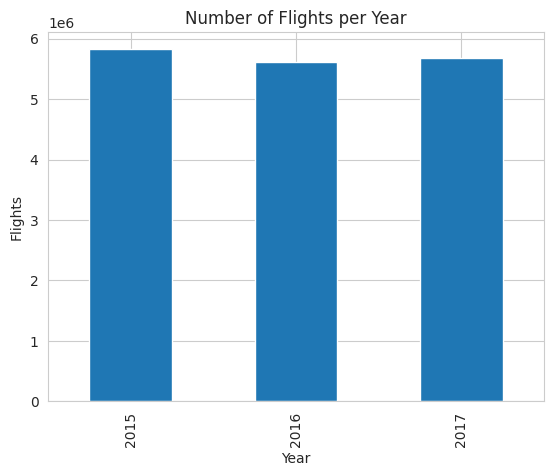

In [26]:
import matplotlib.pyplot as plt

df.groupby("YEAR").size().plot(kind="bar")
plt.title("Number of Flights per Year")
plt.xlabel("Year")
plt.ylabel("Flights")
plt.show()

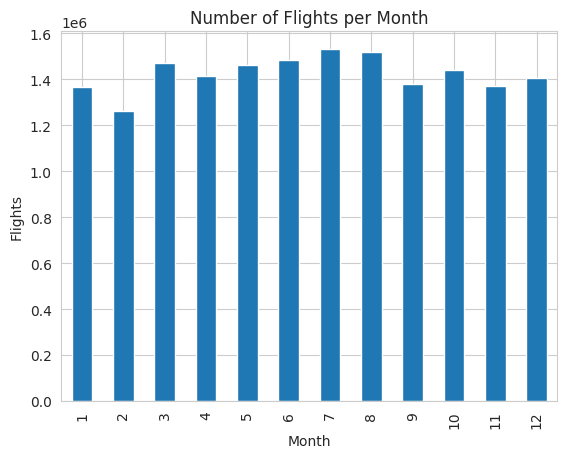

In [27]:
df.groupby("MONTH").size().plot(kind="bar")
plt.title("Number of Flights per Month")
plt.xlabel("Month")
plt.ylabel("Flights")
plt.show()



Flight volume is relatively balanced across years, indicating consistent dataset coverage. Monthly distribution is also stable, with a slight increase in summer months (June–August), likely due to higher travel demand during vacation season.

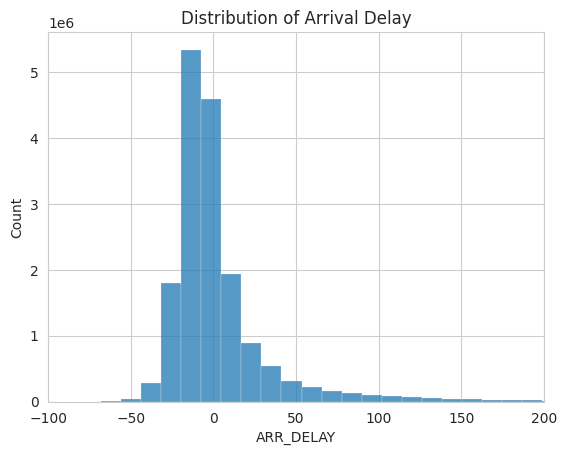

In [28]:
sb.histplot(df["ARR_DELAY"].dropna(),bins=200)
plt.title("Distribution of Arrival Delay")
plt.xlim(-100,200)
plt.show()

Arrival delay distribution is heavily skewed toward negative values, indicating that many flights arrive earlier than scheduled. This reflects conservative scheduling and operational variability in flight durations.

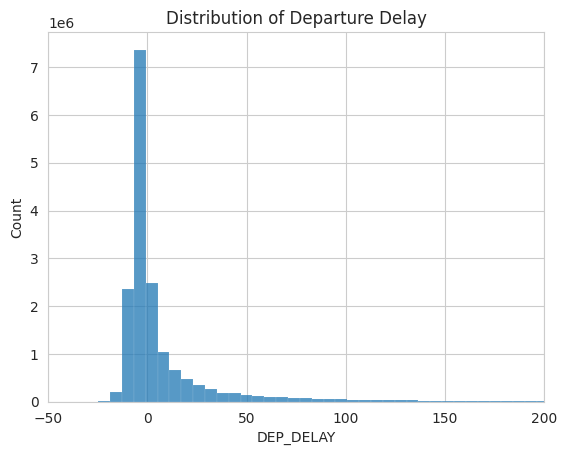

In [29]:
sb.histplot(df["DEP_DELAY"].dropna(),bins=500)
plt.title("Distribution of Departure Delay")
plt.xlim(-50, 200)
plt.show()

Departure delays are mostly centered around zero with a slight negative skew, suggesting that early or on-time departures are common, likely due to scheduling buffers and operational efficiency.

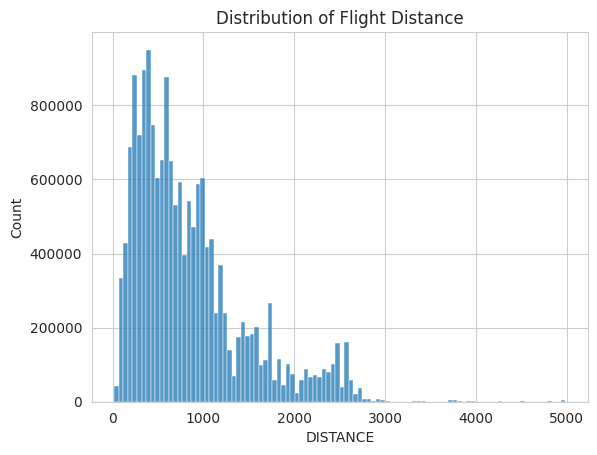

In [30]:
sb.histplot(df["DISTANCE"].dropna(), bins=100)
plt.title("Distribution of Flight Distance")
plt.show()

The dataset is dominated by short to medium-haul flights, which is expected for domestic US airline operations.

## Categorical Variable Analysis

This section examines the distribution of key categorical variables such as airlines and airports.

The analysis focuses on identifying the busiest carriers and airports, as well as measuring cancellation and diversion frequencies across the dataset.

In [31]:
top_carriers = (
    df["OP_CARRIER"]
    .value_counts()
    .head(10)
)
top_carriers

OP_CARRIER
WN    3890743
DL    2722187
AA    2536827
OO    1900813
UA    1645271
EV    1402508
B6     848175
AS     534869
NK     412396
MQ     294632
Name: count, dtype: int64

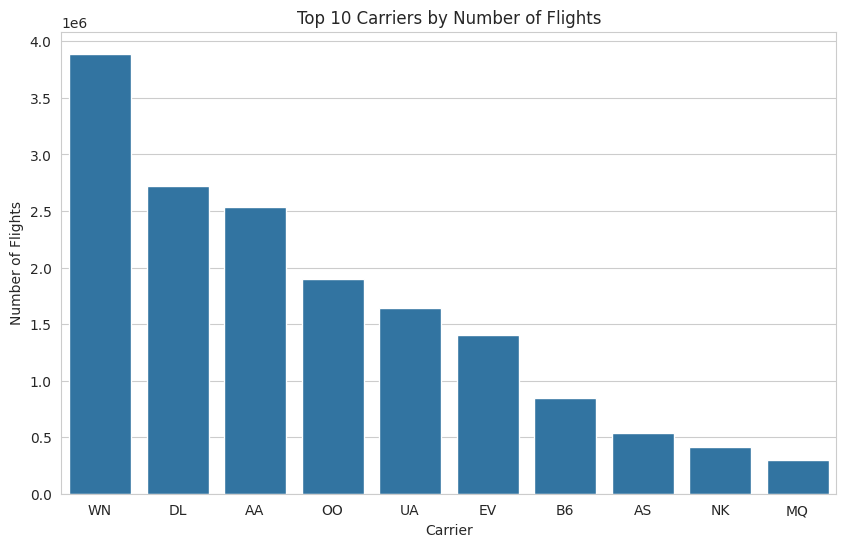

In [32]:
plt.figure(figsize=(10,6))
sb.barplot(
    x=top_carriers.index,
    y=top_carriers.values
)
plt.title("Top 10 Carriers by Number of Flights")
plt.xlabel("Carrier")
plt.ylabel("Number of Flights")

plt.show()

The carriers `WN`, `DL`, `AA`, and `OO` account for the largest share of flights in the dataset, indicating strong concentration among a few major airlines.

In [33]:
top_origins = (
    df["ORIGIN"]
    .value_counts()
    .head(10)
)

top_origins

ORIGIN
ATL    1128454
ORD     824078
DEN     663492
LAX     639681
DFW     637852
SFO     509167
PHX     473370
LAS     448275
IAH     426196
SEA     391088
Name: count, dtype: int64

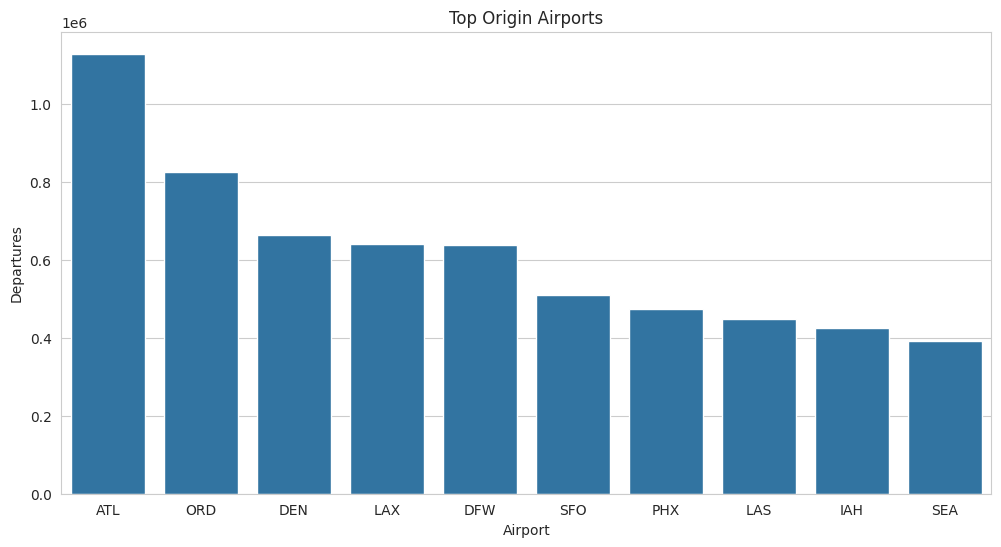

In [34]:
plt.figure(figsize=(12, 6))
sb.barplot(
    x=top_origins.index,
    y=top_origins.values
)

plt.title("Top Origin Airports")
plt.xlabel("Airport")
plt.ylabel("Departures")

plt.show()

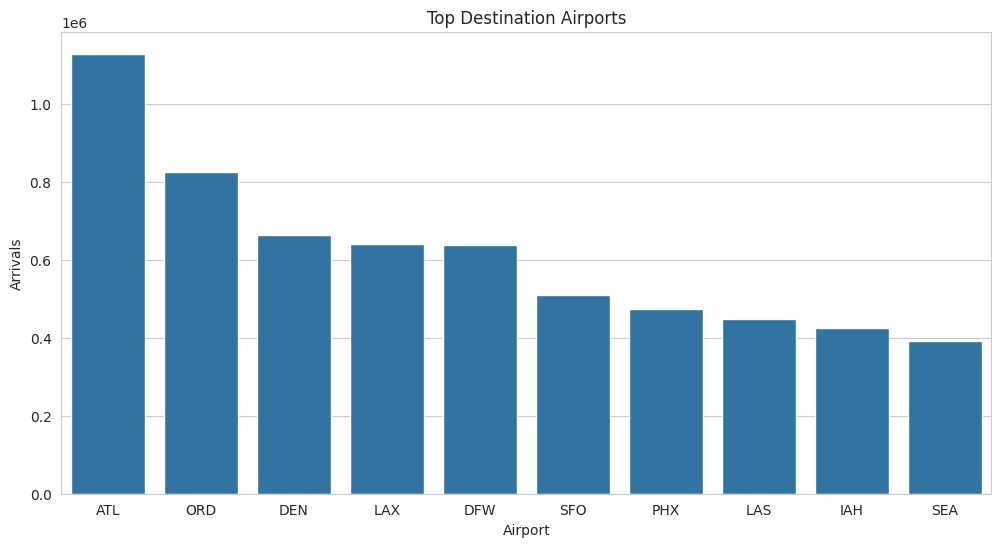

In [35]:
top_destinations = (
    df["DEST"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

sb.barplot(
    x=top_destinations.index,
    y=top_destinations.values
)

plt.title("Top Destination Airports")
plt.xlabel("Airport")
plt.ylabel("Arrivals")

plt.show()

Airports such as `ATL`, `ORD`, and `DEN` dominate both departures and arrivals, reflecting their role as major domestic airline hubs in the United States.

In [36]:
cancellation_rate = (
    df["CANCELLED"]
    .mean() * 100
)

print(cancellation_rate)

1.3934487256943604


In [37]:
diversion_rate = (
    df["DIVERTED"]
    .mean() * 100
)

print(diversion_rate)

0.2417633948164722


Flight cancellations and diversions are relatively rare events, with cancellation and diversion rates remaining low compared to the total number of flights.

# Time Patterns
This section investigates how delays, cancellations, and flight activity vary over time.

Monthly and yearly trends are examined to identify seasonal effects and long-term operational patterns in domestic air travel.

In [38]:
monthly_delay = (
    df.groupby("MONTH")["ARR_DELAY"]
    .mean()
)

monthly_delay

MONTH
1     4.796336
2     3.216038
3     4.135460
4     3.726855
5     4.264256
6     8.639956
7     8.340011
8     6.422031
9    -0.277791
10    0.056138
11   -1.293929
12    6.103902
Name: ARR_DELAY, dtype: float64

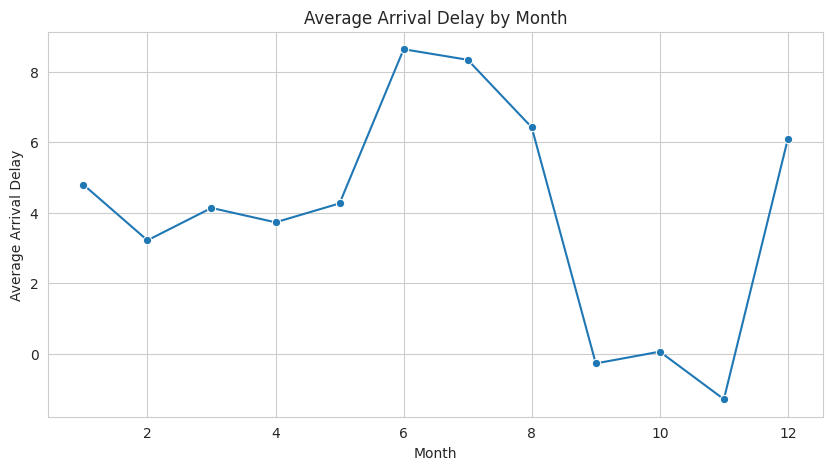

In [39]:
plt.figure(figsize=(10, 5))

sb.lineplot(
    x=monthly_delay.index,
    y=monthly_delay.values,
    marker="o"
)

plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay")

plt.show()

In [40]:
yearly_delay = (
    df.groupby("YEAR")["ARR_DELAY"]
    .mean()
)

yearly_delay

YEAR
2015    4.407057
2016    3.519290
2017    4.326357
Name: ARR_DELAY, dtype: float64

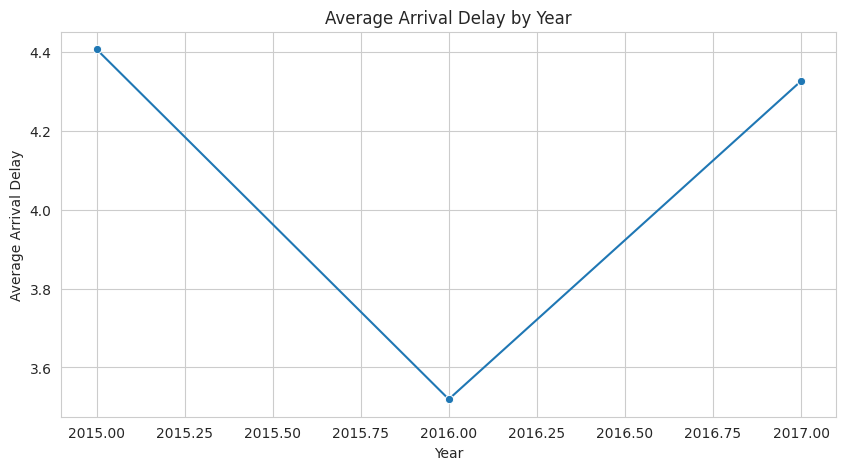

In [41]:
plt.figure(figsize=(10, 5))

sb.lineplot(
    x=yearly_delay.index,
    y=yearly_delay.values,
    marker="o"
)

plt.title("Average Arrival Delay by Year")
plt.xlabel("Year")
plt.ylabel("Average Arrival Delay")

plt.show()

In [42]:
cancel_rate_year = (
    df.groupby("YEAR")["CANCELLED"]
    .mean() * 100
)

cancel_rate_year

YEAR
2015    1.544643
2016    1.172392
2017    1.457243
Name: CANCELLED, dtype: float64

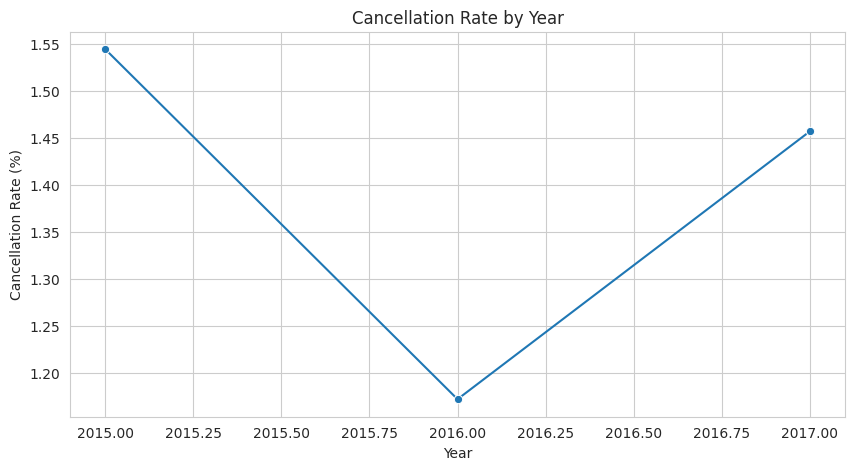

In [43]:
plt.figure(figsize=(10, 5))

sb.lineplot(
    x=cancel_rate_year.index,
    y=cancel_rate_year.values,
    marker="o"
)

plt.title("Cancellation Rate by Year")

plt.xlabel("Year")

plt.ylabel("Cancellation Rate (%)")

plt.show()

### Relationship Between Delays and Flight Cancellations
To further investigate operational disruptions, the relationship between average arrival delays and cancellation rates was explored across different years.

This comparison helps identify whether periods with higher delays also tend to experience increased flight cancellations, potentially reflecting broader operational congestion or adverse conditions.

In [44]:
yearly_analysis = (
    df.groupby("YEAR")
    .agg({
        "ARR_DELAY": "mean",
        "CANCELLED": "mean"
    })
)

yearly_analysis["CANCELLED"] *= 100

yearly_analysis

,ARR_DELAY,CANCELLED
YEAR,,
2015,4.407057,1.544643
2016,3.519290,1.172392
2017,4.326357,1.457243


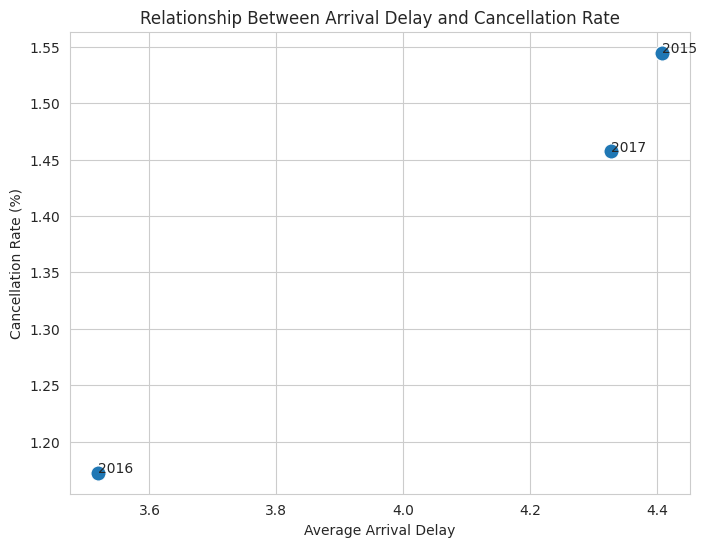

In [45]:
plt.figure(figsize=(8, 6))

sb.scatterplot(
    data=yearly_analysis,
    x="ARR_DELAY",
    y="CANCELLED",
    s=120
)

for year in yearly_analysis.index:
    plt.text(
        yearly_analysis.loc[year, "ARR_DELAY"],
        yearly_analysis.loc[year, "CANCELLED"],
        str(year)
    )

plt.title("Relationship Between Arrival Delay and Cancellation Rate")
plt.xlabel("Average Arrival Delay")
plt.ylabel("Cancellation Rate (%)")

plt.show()


The visualization suggests a moderate positive relationship between average arrival delays and cancellation rates. Years with higher delay levels generally tend to exhibit slightly increased cancellation frequencies.

## Day of Week and Time of Day
This section explores how flight delays vary across different days of the week and departure times.

The analysis helps identify temporal operational patterns and periods associated with increased delays.


In [46]:
day_delay = (
    df.groupby("DAY_OF_WEEK")["ARR_DELAY"]
    .mean()
)
day_delay

DAY_OF_WEEK
Friday       5.764270
Monday       5.336877
Saturday     1.730598
Sunday       3.620081
Thursday     5.527441
Tuesday      3.025706
Wednesday    3.111962
Name: ARR_DELAY, dtype: float64

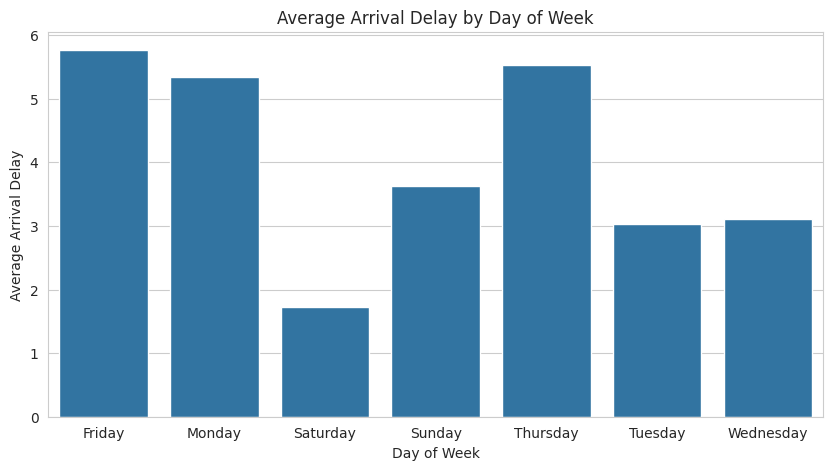

In [47]:
plt.figure(figsize=(10, 5))

sb.barplot(
    x=day_delay.index,
    y=day_delay.values
)

plt.title("Average Arrival Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Arrival Delay")

plt.show()

In [48]:
hourly_delay = (
    df.groupby("DEP_HOUR")["ARR_DELAY"]
    .mean()
)

hourly_delay

DEP_HOUR
0     -0.497996
1      0.696612
2      5.107438
3      5.883547
4      4.406746
5     -4.044179
6     -3.217484
7     -2.085491
8     -0.746921
9      0.419660
10     1.705270
11     2.306341
12     3.478948
13     4.632797
14     6.077040
15     6.933507
16     7.984306
17     9.050572
18    10.220478
19    10.004088
20     9.831574
21     7.828830
22     5.706365
23     3.209258
Name: ARR_DELAY, dtype: float64

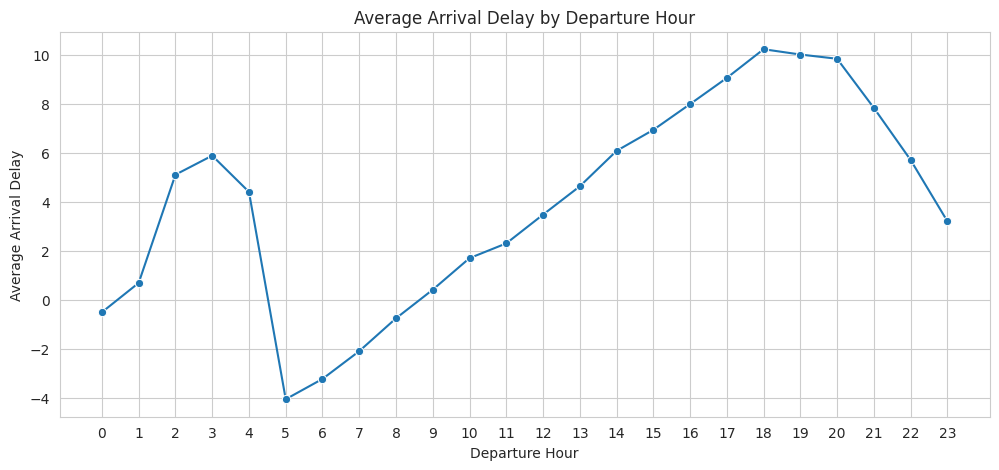

In [49]:
plt.figure(figsize=(12,5))

sb.lineplot(
    x=hourly_delay.index,
    y=hourly_delay.values,
    marker="o"
)

plt.xticks(range(24))
plt.title("Average Arrival Delay by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Average Arrival Delay")

plt.show()

In [50]:
time_of_day_delay = (
    df.groupby("TIME_OF_DAY")["ARR_DELAY"]
    .mean()
)

time_of_day_delay

TIME_OF_DAY
Afternoon        6.389877
Early Morning   -2.846817
Evening          9.013238
Late Night       0.487227
Morning          0.894500
Name: ARR_DELAY, dtype: float64

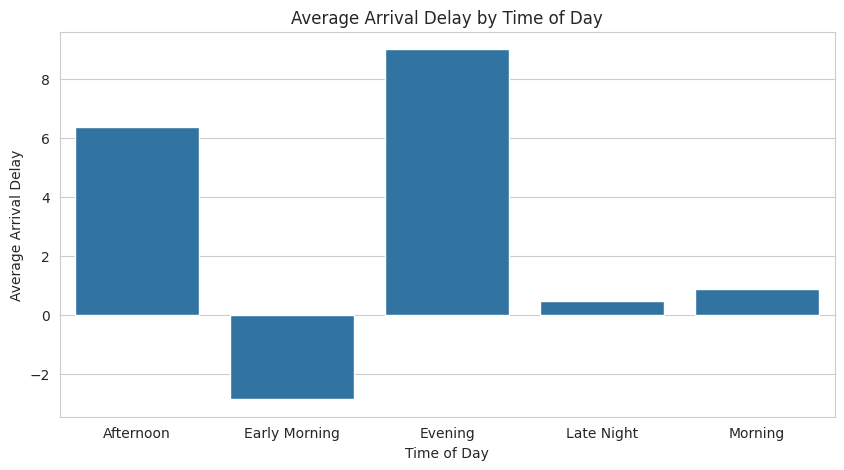

In [51]:
plt.figure(figsize=(10, 5))

sb.barplot(
    x=time_of_day_delay.index,
    y=time_of_day_delay.values
)

plt.title("Average Arrival Delay by Time of Day")

plt.xlabel("Time of Day")

plt.ylabel("Average Arrival Delay")

plt.show()

Flight delays exhibit clear temporal patterns across both weekdays and departure hours.

Higher average delays are observed on Mondays, Thursdays, and Fridays, possibly reflecting increased travel demand and operational congestion during business and weekend travel periods. Saturdays show the lowest average delays, consistent with reduced traffic volume.

Delay levels are also strongly associated with departure time. Flights departing during early morning hours experience the lowest delays, while delays gradually increase throughout the day and peak during late afternoon and evening hours. This pattern is consistent with delay propagation effects, where operational disruptions accumulate over the course of the day.

## Carrier Performance Analysis

Airlines were compared based on their average arrival delays in order to evaluate operational performance and reliability.

This analysis helps identify carriers with relatively better on-time performance as well as airlines with consistently higher delays.

In [52]:
carrier_delay = (
    df.groupby("OP_CARRIER")["ARR_DELAY"]
    .mean()
    .sort_values()
)

carrier_delay

OP_CARRIER
AS   -0.827096
DL   -0.153951
HA    1.292410
UA    2.898983
US    3.706209
AA    4.182379
WN    4.446431
OO    5.798531
MQ    6.457873
EV    6.531578
VX    7.877673
F9    8.522853
B6    8.639344
NK    9.390782
Name: ARR_DELAY, dtype: float64

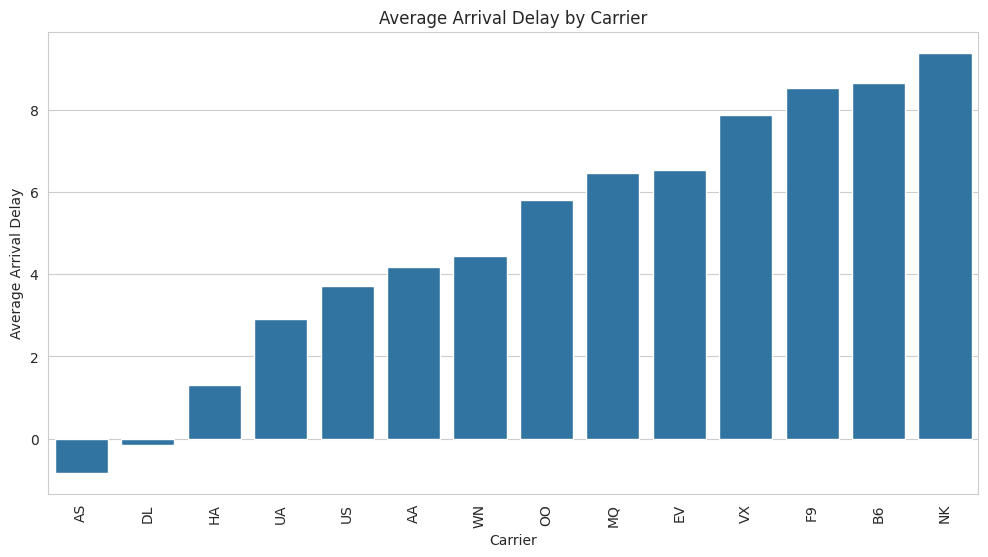

In [53]:
plt.figure(figsize=(12, 6))

sb.barplot(
    x=carrier_delay.index,
    y=carrier_delay.values
)

plt.xticks(rotation=90)
plt.title("Average Arrival Delay by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Average Arrival Delay")
plt.show()

The analysis shows noticeable differences in average arrival delays between carriers. Some airlines achieve near on-time average arrivals, while others exhibit consistently higher delays, suggesting variation in operational efficiency and scheduling performance.

In [54]:
carrier_variance = (
    df.groupby("OP_CARRIER")["ARR_DELAY"]
    .std()
    .sort_values()
)
carrier_variance

OP_CARRIER
HA    26.665676
AS    29.098676
WN    31.576466
US    32.378743
VX    38.978571
DL    42.410992
MQ    44.458112
AA    44.680010
UA    44.987786
B6    46.391167
NK    48.389107
OO    49.691219
EV    50.410947
F9    50.620842
Name: ARR_DELAY, dtype: float64

In [55]:
carrier_stats = (
    df.groupby("OP_CARRIER")["ARR_DELAY"]
    .agg(["mean","var","std","count"])
    .sort_values(by="mean")
)
carrier_stats

,mean,var,std,count
OP_CARRIER,,,,
AS,-0.827096,846.732961,29.098676,530508
DL,-0.153951,1798.692253,42.410992,2699963
HA,1.292410,711.058263,26.665676,232489
UA,2.898983,2023.900875,44.987786,1623164
US,3.706209,1048.383000,32.378743,194223
AA,4.182379,1996.303271,44.680010,2496565
WN,4.446431,997.073222,31.576466,3831906
OO,5.798531,2469.217266,49.691219,1866406
MQ,6.457873,1976.523738,44.458112,278791


#  Carriers, Airports, and Routes
This section compares operational performance across airlines and airports.

The analysis focuses on average delays, cancellation behavior, and airport activity patterns to better understand differences in operational efficiency across the domestic flight network.

In [56]:
carrier_cancel = (
    df.groupby("OP_CARRIER")["CANCELLED"]
    .mean()
    .mul(100)
    .sort_values()
)

carrier_cancel

OP_CARRIER
HA    0.222524
AS    0.559389
DL    0.620824
F9    0.945727
UA    1.094166
VX    1.106903
WN    1.283945
AA    1.337261
OO    1.518508
B6    1.928965
US    2.046650
NK    2.370052
EV    2.644263
MQ    5.099582
Name: CANCELLED, dtype: float64

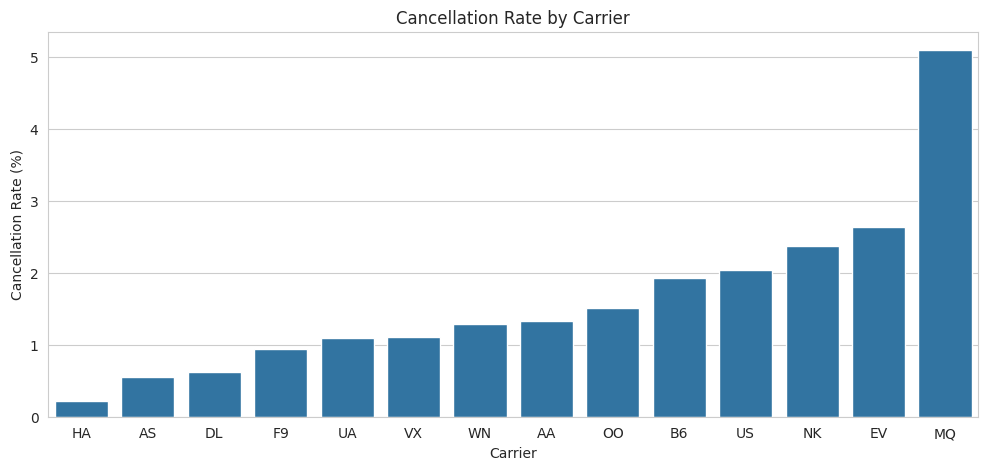

In [57]:
plt.figure(figsize=(12, 5))

sb.barplot(
    x=carrier_cancel.index,
    y=carrier_cancel.values
)

plt.title("Cancellation Rate by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Cancellation Rate (%)")

plt.show()

In [58]:
airport_analysis = (
    df.groupby("ORIGIN")
    .agg({
        "ARR_DELAY": "mean",
        "FL_DATE": "count"
    })
    .rename(columns={
        "FL_DATE": "FLIGHT_COUNT"
    })
)

airport_analysis

,ARR_DELAY,FLIGHT_COUNT
ORIGIN,,
ABE,5.614848,7020
ABI,3.269847,2733
ABQ,3.485723,59035
ABR,6.235133,2213
ABY,6.632215,2586
...,...,...
WRG,0.724284,2180
WYS,4.933333,664
XNA,7.327610,21140


In [59]:
top_airports = (
    airport_analysis
    .sort_values("FLIGHT_COUNT", ascending=False)
    .head(10)
)

top_airports

,ARR_DELAY,FLIGHT_COUNT
ORIGIN,,
ATL,2.688680,1128454
ORD,7.132308,824078
DEN,4.418602,663492
LAX,5.955089,639681
DFW,6.998767,637852
SFO,7.179317,509167
PHX,3.190105,473370
LAS,5.418658,448275
IAH,3.632837,426196


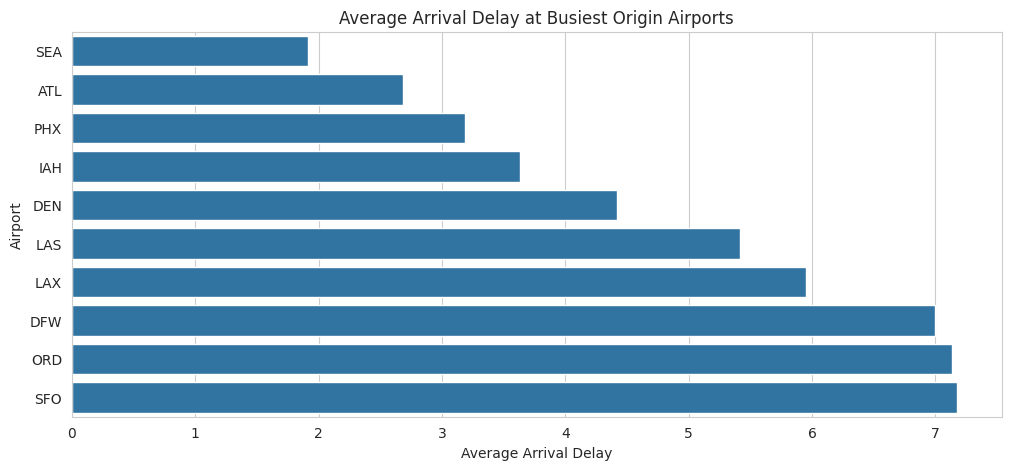

In [60]:
plt.figure(figsize=(12, 5))

sb.barplot(
    data=top_airports.sort_values("ARR_DELAY"),
    x="ARR_DELAY",
    y=top_airports.sort_values("ARR_DELAY").index
)

plt.title("Average Arrival Delay at Busiest Origin Airports")
plt.xlabel("Average Arrival Delay")
plt.ylabel("Airport")

plt.show()

Substantial differences are observed across airlines in terms of cancellation behavior. Hawaiian Airlines (HA), Alaska Airlines (AS), and Delta Airlines (DL) exhibit the lowest cancellation rates, while Mesa Airlines (MQ) shows a noticeably higher cancellation frequency.

Airport-level analysis also reveals operational differences among major hubs. Although Atlanta (ATL) handles the highest flight volume in the dataset, its average arrival delay remains relatively moderate, suggesting comparatively efficient traffic management. In contrast, airports such as Chicago O'Hare (ORD) and San Francisco (SFO) exhibit higher average delays, likely reflecting heavier congestion and operational complexity.

## Correlation and Causes
This section explores relationships between numerical delay variables and investigates the dominant operational causes of flight delays.

The analysis includes correlation patterns between delay measures and a summary of the most frequently reported delay causes among significantly delayed flights.

### Dominant Delay Causes

To better understand operational disruptions, the analysis identifies the dominant delay cause for flights with arrival delays of at least 15 minutes.

For each delayed flight, the delay category with the largest reported delay minutes is selected as the primary operational cause.

In [70]:
delayed_flights = df[df["ARR_DELAY"] >= 15]

main_cause_counts = (
    delayed_flights["MAIN_DELAY_CAUSE"]
    .value_counts()
)
main_cause_counts

MAIN_DELAY_CAUSE
LATE_AIRCRAFT_DELAY    1190665
NAS_DELAY               905330
CARRIER_DELAY           861620
WEATHER_DELAY            94161
SECURITY_DELAY            5375
NO_REPORTED_DELAY            1
Name: count, dtype: int64

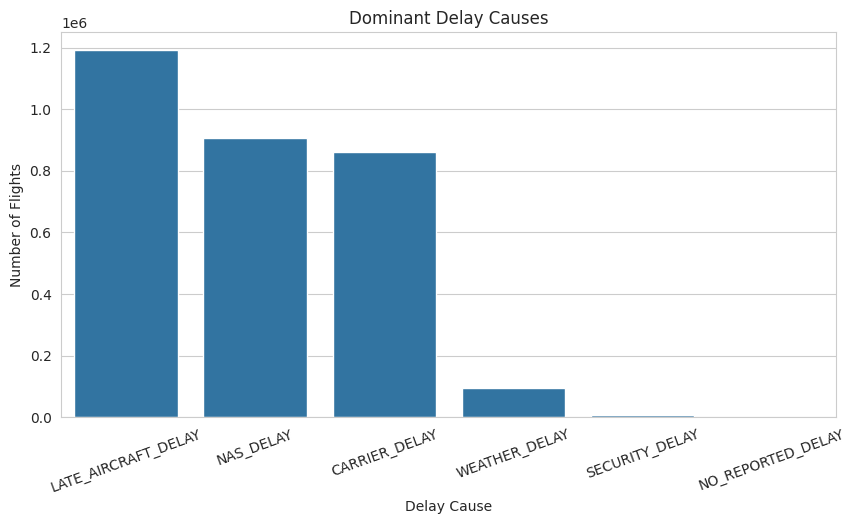

In [71]:
plt.figure(figsize=(10, 5))

sb.barplot(
    x=main_cause_counts.index,
    y=main_cause_counts.values
)

plt.title("Dominant Delay Causes")
plt.xlabel("Delay Cause")
plt.ylabel("Number of Flights")
plt.xticks(rotation=20)

plt.show()